In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import constants, units
from astropy.coordinates import Angle
from scipy.optimize import curve_fit
import pandas as pd
import os
from scipy.signal import medfilt
from astropy.wcs import WCS
import scipy.integrate as integrate
from astropy.coordinates import SkyCoord
from gwcs.wcstools import wcs_from_points
import astropy.coordinates as coord
from matplotlib.lines import Line2D

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Load in the full catalog

In [4]:
df = pd.read_csv(rootdir+'ldss_photometry_final.dat')

In [5]:
df

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z
0,231.087323,9.960302,-1.0000,21.0268,-1.0000,-1.0,-1.0,-1.0,-1.0
1,231.087641,9.959497,-1.0000,19.7528,-1.0000,-1.0,-1.0,-1.0,-1.0
2,231.117408,9.965167,-1.0000,21.1236,27.4169,-1.0,-1.0,-1.0,-1.0
3,231.118858,9.964090,-1.0000,19.4755,-1.0000,-1.0,-1.0,-1.0,-1.0
4,231.091122,9.953285,-1.0000,24.3223,-1.0000,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...
1109,231.092249,9.987659,23.5290,24.0699,27.5635,-1.0,-1.0,-1.0,-1.0
1110,231.115917,9.960264,24.7600,25.1467,-1.0000,-1.0,-1.0,-1.0,-1.0
1111,231.099336,9.989730,23.8963,23.6488,26.8201,-1.0,-1.0,-1.0,-1.0
1112,231.087405,9.986115,-1.0000,25.2002,-1.0000,-1.0,-1.0,-1.0,-1.0


Compute the separation of all objects from the QSO

In [6]:
df['theta'] = -1*np.ones(len(df))

In [7]:
def calc_phi(alpha_1, delta_1, alpha_2, delta_2):
    
    cos_phi = np.dot([np.cos(delta_1)*np.cos(alpha_1), np.cos(delta_1)*np.sin(alpha_1), np.sin(delta_1)],
                      [np.cos(delta_2)*np.cos(alpha_2), np.cos(delta_2)*np.sin(alpha_2), np.sin(delta_2)])
    
    phi = np.arccos(cos_phi)
    
    return phi

In [8]:
qso_ra = 231.1021728515625
qso_dec = 9.974760055541992

In [9]:
for i in range(len(df)):

    ra = Angle(df.loc[i]['RA'], units.deg).rad
    dec = Angle(df.loc[i]['Dec'], units.deg).rad

    df.loc[i,'theta'] = (calc_phi(ra, dec, qso_ra*np.pi/180, qso_dec*np.pi/180)*units.rad).to(units.arcsecond).value

In [10]:
df

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta
0,231.087323,9.960302,-1.0000,21.0268,-1.0000,-1.0,-1.0,-1.0,-1.0,74.036769
1,231.087641,9.959497,-1.0000,19.7528,-1.0000,-1.0,-1.0,-1.0,-1.0,75.328043
2,231.117408,9.965167,-1.0000,21.1236,27.4169,-1.0,-1.0,-1.0,-1.0,64.113375
3,231.118858,9.964090,-1.0000,19.4755,-1.0000,-1.0,-1.0,-1.0,-1.0,70.535991
4,231.091122,9.953285,-1.0000,24.3223,-1.0000,-1.0,-1.0,-1.0,-1.0,86.672083
...,...,...,...,...,...,...,...,...,...,...
1109,231.092249,9.987659,23.5290,24.0699,27.5635,-1.0,-1.0,-1.0,-1.0,58.261841
1110,231.115917,9.960264,24.7600,25.1467,-1.0000,-1.0,-1.0,-1.0,-1.0,71.402924
1111,231.099336,9.989730,23.8963,23.6488,26.8201,-1.0,-1.0,-1.0,-1.0,54.824151
1112,231.087405,9.986115,-1.0000,25.2002,-1.0000,-1.0,-1.0,-1.0,-1.0,66.428578


In [11]:
# LDSS m1 redshifts
df.iloc[884]['z'] = 0.6518
df.iloc[757]['z'] = 0.8415
df.iloc[941]['z'] = 1.3316

# LDSS m2 redshifts
df.iloc[536]['z'] = 1.4378
df.iloc[22]['z'] = 1.2988
df.iloc[328]['z'] = 0.6164

Compute projected distances

In [12]:
def d_A(z, H0=70, Omega_m=0.3, Omega_lam=0.7):
    
    d_H = (constants.c/(H0*(units.km * units.s**-1 * units.Mpc**-1))).to(units.kpc)
    
    z_arr = np.arange(0, z+0.01, 0.01)
    E_arr = (Omega_m*(1+z_arr)**3 + Omega_lam)**-0.5
    
    return ((1+z)**-1 * d_H * np.trapz(E_arr, z_arr)).value

In [13]:
d_proj_arr = -np.ones(len(df))

for i in range(len(df)):
    if df.iloc[i]['z'] != -1:
        d_proj_arr[i] = d_A(df.iloc[i]['z'])*((df.iloc[i]['theta']*units.arcsec).to(units.radian)).value
    else:
        d_proj_arr[i] = -1

In [14]:
d_A(1.04431)*((3*units.arcsec).to(units.radian)).value

24.358276216014836

In [15]:
df['d_proj'] = d_proj_arr

Now begin sorting, let us see the distribution of $\theta_{QSO}$

Text(0, 0.5, 'Counts')

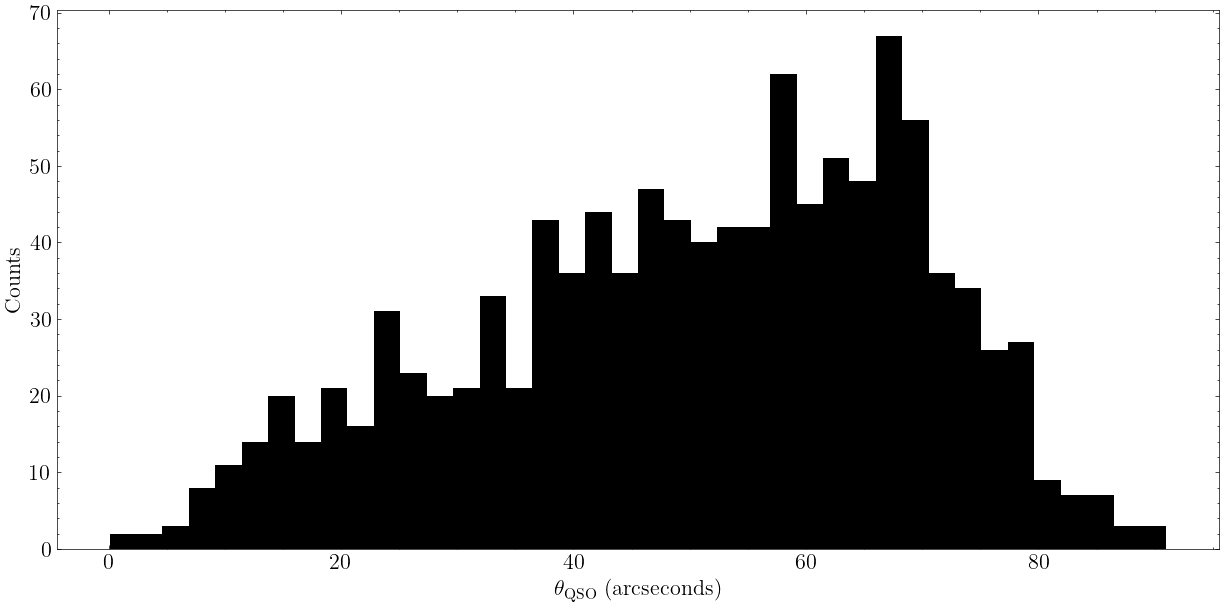

In [16]:
fig, ax = plt.subplots(1, figsize=(15,7))
ax.hist(df['theta'], bins=40)

ax.set_xlabel(r'$\theta_\mathrm{QSO}$ (arcseconds)')
ax.set_ylabel('Counts')

In [17]:
theta_partitions = [0,25,50,75,100]

In [18]:
df_sorted = pd.DataFrame(columns=df.columns)

In [19]:
for i in range(len(theta_partitions)-1):
    
    theta_min = theta_partitions[i]
    theta_max = theta_partitions[i+1]
    
    df_slice = df.loc[(df['theta']>=theta_min)&(df['theta']<=theta_max)].sort_values('f160w_mag')
        
    df_sorted = df_sorted.append(df_slice)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_7392/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_7392/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_7392/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_7392/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.a

In [20]:
df_sorted

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
461,231.106859,9.977688,-1.0000,24.4336,28.6723,-1.0,-1.0,-1.0,-1.0,19.677603,-1.0
359,231.102481,9.980198,-1.0000,25.2037,28.3803,-1.0,-1.0,-1.0,-1.0,19.606745,-1.0
486,231.108777,9.976719,-1.0000,24.2128,28.2345,-1.0,-1.0,-1.0,-1.0,24.455099,-1.0
366,231.096478,9.978184,-1.0000,25.5229,28.8657,-1.0,-1.0,-1.0,-1.0,23.655196,-1.0
367,231.105677,9.980600,-1.0000,23.2307,-1.0000,-1.0,-1.0,-1.0,-1.0,24.421444,-1.0
...,...,...,...,...,...,...,...,...,...,...,...
19,231.095566,9.954785,23.9339,23.5250,-1.0000,-1.0,-1.0,-1.0,-1.0,75.629350,-1.0
33,231.119600,9.961566,24.1524,23.7663,-1.0000,-1.0,-1.0,-1.0,-1.0,77.938865,-1.0
16,231.092749,9.955428,24.1691,23.5231,-1.0000,-1.0,-1.0,-1.0,-1.0,77.202623,-1.0
5,231.091197,9.952817,24.3964,22.6563,-1.0000,-1.0,-1.0,-1.0,-1.0,88.061051,-1.0


In [21]:
df_sorted[df_sorted['z']>1.3]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
507,231.099882,9.972947,21.0600,21.2157,24.5041,26.41,25.64,24.68,1.3348,10.419823,87.752804
581,231.097726,9.969974,22.3301,22.4239,24.6098,25.68,25.13,24.59,1.3392,23.354331,196.313606
469,231.099296,9.974680,22.6299,22.7110,26.7995,26.72,26.31,26.17,1.3641,10.205141,86.130872
536,231.092034,9.969418,21.3055,21.4030,24.1687,-1.00,-1.00,-1.00,1.4378,40.769010,344.697671
428,231.109465,9.979420,21.9302,21.9795,24.6599,25.42,25.01,24.61,1.3379,30.818896,259.203868
590,231.108876,9.970954,22.9621,23.0296,25.9718,27.42,26.62,25.98,1.3303,27.432033,231.470941
706,231.097585,9.967699,23.2743,23.1442,25.2932,26.44,25.81,25.36,1.3393,30.178300,253.664202
548,231.094381,9.970037,23.7932,23.4543,26.7438,27.96,27.22,26.65,1.3390,32.437796,272.691398
650,231.096926,9.969038,23.8461,23.8454,27.2053,27.58,27.51,27.00,1.3379,27.758652,233.465527
941,231.100636,9.960754,20.5755,20.6541,23.8296,-1.00,-1.00,-1.00,1.3316,50.717063,427.710954


In [22]:
df_sorted[df_sorted['z']==0.6780]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
680,231.095997,9.967605,22.0527,21.9529,24.3255,26.62,25.23,24.83,0.678,33.806604,239.037177


In [23]:
3e5*(0.6780-0.67546)/(1+0.67546)

454.8004727060206

In [24]:
#df_sorted[df_sorted['z']==0.7293]

In [25]:
df_sorted[df_sorted['z']==1.0959]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
280,231.099772,9.981098,24.1001,23.8175,26.0512,27.27,27.02,26.37,1.0959,24.351755,199.416435


In [26]:
3e5*(1.0959-1.09457)/(1+1.09457)

190.49255933199464

In [27]:
df_sorted[df_sorted['z']==1.2256]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
451,231.098192,9.976112,22.9471,22.9237,25.3929,26.43,25.96,25.37,1.2256,14.9314,124.50891


In [28]:
3e5*(1.2256-1.22541)/(1+1.22541)

25.61325778170033

In [29]:
df_sorted[df_sorted['z']==1.2787]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
562,231.098092,9.970517,21.891,21.7996,24.4112,27.21,26.16,25.05,1.2787,21.039173,176.062913


In [30]:
3e5*(1.2787-1.27767)/(1+1.27767)

135.66495585399082

In [31]:
df_spec_z = df_sorted[(df_sorted['z']!=-1) & (df_sorted['z']!=0) & (df_sorted['z']<=1.3276)].sort_values('z')

In [32]:
len(df_spec_z)

34

In [33]:
df_spec_z

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
264,231.101562,9.982189,22.3238,22.4280,24.4433,25.21,24.75,24.70,0.0966,26.830391,49.636485
396,231.102948,9.976000,16.7825,16.8165,17.8671,18.95,18.21,17.77,0.1203,5.242843,12.253706
395,231.103384,9.977022,18.1347,18.2139,19.4546,20.07,19.52,19.21,0.1204,9.204546,21.511181
213,231.097411,9.982920,22.6496,22.6584,24.3640,24.54,24.20,23.80,0.1393,33.881520,83.654796
529,231.096240,9.971248,22.7515,22.6032,26.5490,26.85,26.49,26.23,0.2791,24.542556,104.233290
655,231.098210,9.969310,23.9435,24.0014,26.4930,27.39,27.20,26.54,0.2915,24.132906,108.202760
555,231.101887,9.971807,21.6297,21.6032,23.9751,24.56,23.94,23.59,0.3198,10.680617,49.727505
528,231.099128,9.971625,19.1227,19.2642,20.4178,21.97,20.80,20.19,0.3286,15.620245,74.308754
700,231.105232,9.969616,22.9127,22.8976,25.6831,25.62,24.93,24.73,0.3752,21.459975,112.101220
468,231.098332,9.974461,23.3688,23.2136,25.8086,27.39,26.37,25.96,0.3759,13.661293,71.326666


In [34]:
z_list = [str(z) for z in df_spec_z['z']]
d_proj_list = [str(d) for d in df_spec_z['d_proj']]

In [35]:
CIV_EW_list = ['<44', '<50', '<49', '<49', '<105', 
               '<97',#'227, -32, +32', 
               '<157', '<123', '<93', 
               '<95', '<73', '<69', '<59', '<60', '<62', '<47', 
               '<48', 
               '<67', '<67','<67',#'254, -22, +22', '254, -22, +22', '254, -22, +22', 
               '<58','<46', '<52', '<52', 
               '157, -18, +18','<49', '<49', 
               '-10', '-10', '199, -3, +3', 
               '<12', '16, -3, +3', '176, -3, +3', '<8']

In [36]:
df_spec_z['CIV'] = CIV_EW_list

In [37]:
df_spec_z

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj,CIV
264,231.101562,9.982189,22.3238,22.4280,24.4433,25.21,24.75,24.70,0.0966,26.830391,49.636485,<44
396,231.102948,9.976000,16.7825,16.8165,17.8671,18.95,18.21,17.77,0.1203,5.242843,12.253706,<50
395,231.103384,9.977022,18.1347,18.2139,19.4546,20.07,19.52,19.21,0.1204,9.204546,21.511181,<49
213,231.097411,9.982920,22.6496,22.6584,24.3640,24.54,24.20,23.80,0.1393,33.881520,83.654796,<49
529,231.096240,9.971248,22.7515,22.6032,26.5490,26.85,26.49,26.23,0.2791,24.542556,104.233290,<105
655,231.098210,9.969310,23.9435,24.0014,26.4930,27.39,27.20,26.54,0.2915,24.132906,108.202760,<97
555,231.101887,9.971807,21.6297,21.6032,23.9751,24.56,23.94,23.59,0.3198,10.680617,49.727505,<157
528,231.099128,9.971625,19.1227,19.2642,20.4178,21.97,20.80,20.19,0.3286,15.620245,74.308754,<123
700,231.105232,9.969616,22.9127,22.8976,25.6831,25.62,24.93,24.73,0.3752,21.459975,112.101220,<93
468,231.098332,9.974461,23.3688,23.2136,25.8086,27.39,26.37,25.96,0.3759,13.661293,71.326666,<95


In [38]:
np.min(df_spec_z['z']), np.max(df_spec_z['z'])

(0.0966, 1.2988)

# Plot $W_r$ versus $d_\mathrm{proj}$

This sample

In [39]:
z_arr = np.array(df_spec_z['z'])
d_proj_arr = np.array(df_spec_z['d_proj'])
W_arr = list(df_spec_z['CIV'])

Chen+01

In [40]:
c01_arr = np.loadtxt('/Users/thepoetoftwilight/Documents/CUBS/Data/revised_chen01.civ')

d_proj_arr_c01 = c01_arr[:,0]/.7
W_arr_c01 = c01_arr[:,1]
dW_arr_c01 = c01_arr[:,2]
flag_arr_c01 = c01_arr[:,3]
z_arr_c01 = c01_arr[:,4]

In [41]:
np.min(z_arr_c01), np.max(z_arr_c01)

(0.0921, 0.892)

Liang+14 (Sub)

In [42]:
df_l14_sub = pd.read_excel('/Users/thepoetoftwilight/Documents/CUBS/Data/full_catalog_subv4.xlsx')

/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [43]:
#df_l14_sub

In [44]:
d_proj_arr_l14_sub = np.float_(df_l14_sub['imp_dist(kpc)'])
W_arr_l14_sub = np.float_(df_l14_sub['W(CIV1548)'])/1000
dW_arr_l14_sub = np.float_(df_l14_sub['dW(1548)'])/1000
z_arr_l14_sub = np.float_(df_l14_sub['gal_z'])

In [45]:
idx = W_arr_l14_sub!=0

In [46]:
np.sum(idx)

9

In [47]:
d_proj_arr_l14_sub[idx]

array([ 32.432424  ,  39.30282176,  60.641115  ,  74.30470369,
       138.07600254, 192.868363  , 208.217817  , 225.332368  ,
       230.893926  ])

In [48]:
W_arr_l14_sub[idx]

array([0.58590887, 0.30907341, 0.26575392, 0.05860072, 0.05287207,
       0.22019543, 0.09051071, 0.08301023, 0.15472634])

In [49]:
np.min(z_arr_l14_sub), np.max(z_arr_l14_sub)

(0.002389, 0.17597666666666667)

Liang+14 (Full)

In [50]:
df_l14_full = pd.read_excel('/Users/thepoetoftwilight/Documents/CUBS/Data/full_catalog_ions.xlsx')

/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [51]:
#df_l14

In [52]:
d_proj_arr_l14_full = np.float_(df_l14_full['imp_dist(kpc)'])
W_arr_l14_full = np.float_(df_l14_full['W(CIV1548)'])/1000
dW_arr_l14_full = np.float_(df_l14_full['dW(1548)'])/1000
z_arr_l14_full = np.float_(df_l14_full['gal_z'])

In [53]:
idx = W_arr_l14_full!=0

In [54]:
np.sum(idx)

14

In [55]:
d_proj_arr_l14_full[idx]

array([ 32.432424  ,  60.641115  , 230.893926  , 192.868363  ,
       208.217817  , 240.839174  , 242.281241  , 393.06803   ,
         6.75051156,  20.249286  ,  74.30470369, 225.332368  ,
        35.18183576, 138.        ])

In [56]:
W_arr_l14_full[idx]

array([0.58590887, 0.26575392, 0.15472634, 0.22019543, 0.09051071,
       0.25019237, 0.17798263, 0.03027273, 0.13514458, 0.75607771,
       0.05860072, 0.08301023, 0.11253201, 0.062     ])

In [57]:
np.min(z_arr_l14_full), np.max(z_arr_l14_full)

(0.0022066666666666667, 0.17597666666666667)

Compare two catalogs from LC14

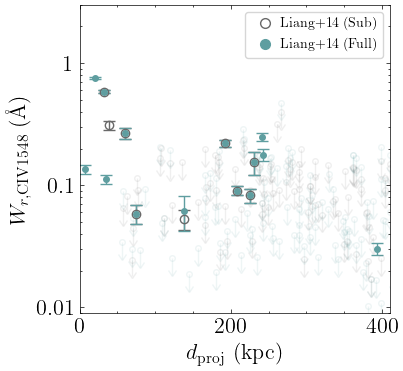

In [58]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# Liang+14 (Sub)
c = 'dimgrey'
p3 = Line2D([0], [0], label=r'Liang+14 (Sub)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor='none', linestyle='')

for i in range(len(d_proj_arr_l14_sub)):
    
    d_proj = d_proj_arr_l14_sub[i]
    W = W_arr_l14_sub[i]
    dW = dW_arr_l14_sub[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', markerfacecolor='none', color=c, 
                         marker='o', markersize=6)
        
# Liang+14 (Full)
c = 'cadetblue'
p6 = Line2D([0], [0], label=r'Liang+14 (Full)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14_full)):
    
    d_proj = d_proj_arr_l14_full[i]
    W = W_arr_l14_full[i]
    dW = dW_arr_l14_full[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

ax.set_xlim(0,410)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p3,p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1)

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

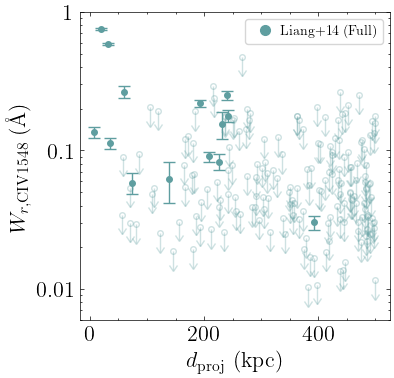

In [59]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# Liang+14 (Full)
c = 'cadetblue'
p6 = Line2D([0], [0], label=r'Liang+14 (Full)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14_full)):
    
    d_proj = d_proj_arr_l14_full[i]
    W = W_arr_l14_full[i]
    dW = dW_arr_l14_full[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

#ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1)

ax.set_yscale('log')
#ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

Liang+14 (published)

In [60]:
l14_arr = np.loadtxt('/Users/thepoetoftwilight/Documents/CUBS/Data/absorber_table.dat', dtype='str')

In [61]:
d_proj_arr_l14 = np.float_(l14_arr[:,2])
W_arr_l14 = np.float_(l14_arr[:,-2])/1000
dW_arr_l14 = np.float_(l14_arr[:,-1])/1000
z_arr_l14 = np.float_(l14_arr[:,3])

In [62]:
idx = W_arr_l14!=0

In [63]:
np.sum(idx)

9

In [64]:
d_proj_arr_l14[idx]

array([ 32.4,  39.3,  60.6,  74.3, 138.1, 192.9, 208.2, 225.3, 230.9])

In [65]:
W_arr_l14[idx]

array([0.586, 0.309, 0.266, 0.059, 0.053, 0.22 , 0.091, 0.083, 0.155])

In [66]:
np.min(z_arr_l14), np.max(z_arr_l14)

(0.0024, 0.176)

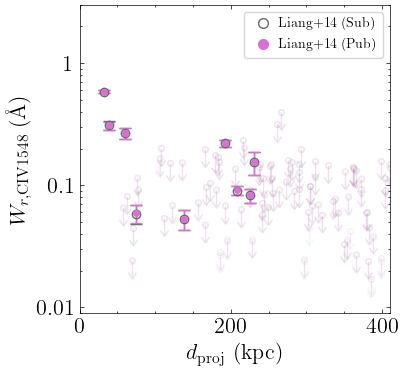

In [76]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# Liang+14 (Sub)
c = 'dimgrey'
p3 = Line2D([0], [0], label=r'Liang+14 (Sub)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor='none', linestyle='')

for i in range(len(d_proj_arr_l14_sub)):
    
    d_proj = d_proj_arr_l14_sub[i]
    W = W_arr_l14_sub[i]
    dW = dW_arr_l14_sub[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', markerfacecolor='none', color=c, 
                         marker='o', markersize=6)
        
# Liang+14 (Pub)
c = 'orchid'
p6 = Line2D([0], [0], label=r'Liang+14 (Pub)', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.1)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.1)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

ax.set_xlim(0,410)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p3,p6])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1)

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

Bordoloi+14

In [67]:
d_proj_arr_b14 = np.array([52,95,90,84,101,65,37,47,37,103,37,77,14,28,15,92,29,
                           125,119,102,120,58,87,135,116,90,89,135,105,101,126,
                           41,124,66,39,55,97,134,114,58,54,53,33])

W_list_b14 = ['173,22', '106,18', '437,33', '393,41', '158,44', '149,39', '406,30',
          '111,35', '152,34', '180,43', '605,28', '452,38', '824,38', '258,83',
          '511,48', '95,30', '201,42', '<14','<19','<18','<20','<16','<58','<18','<17','<29',
          '<44','<15','<28','<21','<34','<16','<17','<59','<45','<39','<35','<25','<32','<29',
          '<19','<19','<25']

W_lim_list_b14 = np.array([30,30,36,57,54,51,51,48,42,75,42,54,42,144,87,54,87,30,45,39,45,36,120,39,
                  39,45,114,30,51,48,72,36,39,156,72,63,72,57,72,39,42,51,45])

z_arr_b14 = np.array([0.017,0.014,0.048,0.055,0.027,0.011,0.034,0.032,0.021,0.030,0.018,0.052,0.059,
             0.062,0.095,0.051,0.095,0.024,0.048,0.023,0.010,0.039,0.036,0.013,0.025,0.023,0.023,0.011,
             0.013,0.026,0.029,0.010,0.026,0.015,0.074,0.104,0.032,0.022,0.028,0.047,0.012,0.018,0.030])

In [68]:
np.min(z_arr_b14), np.max(z_arr_b14)

(0.01, 0.104)

Borthakur+13

In [69]:
d_proj_arr_b13 = np.array([193.9,178.5,171.9,179.1,164.6,152.1,186.6,179.8,88.7,
                           187.4,197.2,196.1,175.5,140.2,146.9,177.0,64.7,103.2,150.9,131.0])

W_list_b13 = ['','<160','<199','<121','928,86','779,172','<295','<231','1224,72','<261','689,37',
            '550,100','','<223','627,105','<248','<134','<485','','<154']

z_arr_b13 = np.array([0.236,0.257,0.297,0.297,0.297,0.295,0.212,0.256,0.473,0.817,0.785,0.195,
                      0.206,0.269,1.240,0.558,0.399,0.229,0.471,0.193])

In [70]:
np.min(z_arr_b13), np.max(z_arr_b13)

(0.193, 1.24)

Make plot

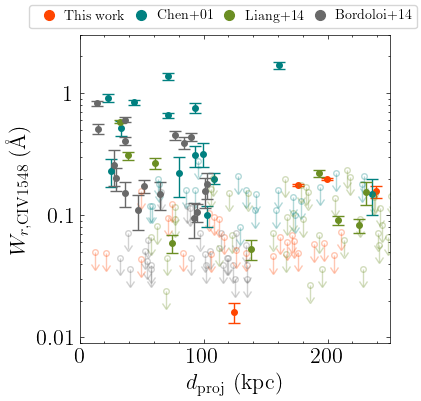

In [93]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.35
handles, labels = plt.gca().get_legend_handles_labels()

# This sample

c = 'orangered'
p1 = Line2D([0], [0], label=r'This work', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr)):
    
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])/1000 # mA to A
        
        
        # Handle d_proj
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)   
    
    elif W_str !='-10':
        W_split = W_str.split(',')
        W = float(W_split[0])/1000
        dW = float(W_split[2])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Chen+01

c = 'teal'
p2 = Line2D([0], [0], label=r'Chen+01', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_c01)):
    
    d_proj = d_proj_arr_c01[i]
    W = W_arr_c01[i]
    dW = dW_arr_c01[i]
    f = flag_arr_c01[i]
    
    if f==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Liang+14
c = 'olivedrab'
p3 = Line2D([0], [0], label=r'Liang+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Bordoloi+14
c = 'dimgrey'
p4 = Line2D([0], [0], label=r'Bordoloi+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b14)):
    
    d_proj = d_proj_arr_b14[i]
    W_str = W_list_b14[i]
    W_lim = W_lim_list_b14[i]/1000 # mA to A
    
    if W_str[0]=='<': # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p1,p2,p3,p4])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=4, columnspacing=0.2,handletextpad=0.1,bbox_to_anchor=(1.11, 1.12))

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

plt.savefig(rootdir+'Figures/CIV_sample.pdf', dpi=300)

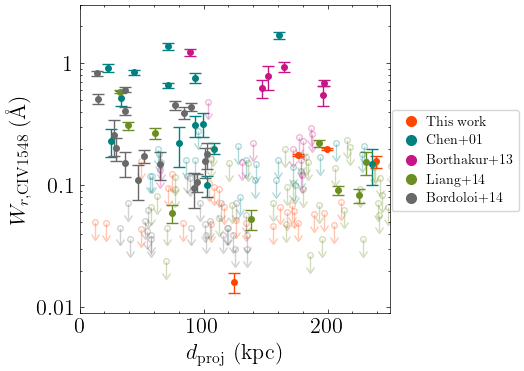

In [78]:
fig, ax = plt.subplots(1, figsize=(4,4), sharey=True)

dy_draw = 45/1000
dy_scale = 1.3
handles, labels = plt.gca().get_legend_handles_labels()

# This sample

c = 'orangered'
p1 = Line2D([0], [0], label=r'This work', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr)):
    
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])/1000 # mA to A
        
        
        # Handle d_proj
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)   
    
    elif W_str !='-10':
        W_split = W_str.split(',')
        W = float(W_split[0])/1000
        dW = float(W_split[2])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Chen+01

c = 'teal'
p2 = Line2D([0], [0], label=r'Chen+01', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_c01)):
    
    d_proj = d_proj_arr_c01[i]
    W = W_arr_c01[i]
    dW = dW_arr_c01[i]
    f = flag_arr_c01[i]
    
    if f==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W, xerr=None, yerr=W/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W, xerr=None, yerr=[[dy_scale*W/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)
        
# Liang+14
c = 'olivedrab'
p3 = Line2D([0], [0], label=r'Liang+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_l14)):
    
    d_proj = d_proj_arr_l14[i]
    W = W_arr_l14[i]
    dW = dW_arr_l14[i]
    
    if W==0: # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, 3*dW, xerr=None, yerr=3*dW/5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, 3*dW, xerr=None, yerr=[[dy_scale*3*dW/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Bordoloi+14
c = 'dimgrey'
p4 = Line2D([0], [0], label=r'Bordoloi+14', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b14)):
    
    d_proj = d_proj_arr_b14[i]
    W_str = W_list_b14[i]
    W_lim = W_lim_list_b14[i]/1000 # mA to A
    
    if W_str[0]=='<': # Non-detection
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

# Borthakur+13
c = 'mediumvioletred'
p5 = Line2D([0], [0], label=r'Borthakur+13', marker='o', markersize=7, 
         markeredgecolor=c, markerfacecolor=c, linestyle='')

for i in range(len(d_proj_arr_b13)):
    
    d_proj = d_proj_arr_b13[i]
    W_str = W_list_b13[i]
    
    if W_str == '':
        pass
    
    elif W_str[0]=='<': # Non-detection
        W_lim = float(W_str[1:])/1000 # mA to A
        (_,caps,_) = ax.errorbar(d_proj, W_lim, xerr=None, yerr=W_lim/5, 
                                 uplims=True, marker='o',
                                 markersize=4, capsize=0, elinewidth=0,
                                 color=c, markerfacecolor='none', alpha=.3)
        caps[0].set_fillstyle('none')
        
        # Connect
        ax.errorbar(d_proj, W_lim, xerr=None, yerr=[[dy_scale*W_lim/5],[0]], markersize=0,
                   linestyle='none', capsize=0, color=c, alpha=.3)      
        
    else: # Detection
        W_str_split = W_str.split(',')
        W = float(W_str_split[0])/1000 # mA to A
        dW = float(W_str_split[1])/1000
        
        ax.errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color=c, 
                         marker='o', markersize=4)

        
ax.set_xlim(0,250)
ax.set_xlabel(r'$d_\mathrm{proj}$ (kpc)')
ax.set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


# add manual symbols to auto legend
handles.extend([p1,p2,p5,p3,p4])

plt.subplots_adjust(wspace=0, hspace=0)
plt.legend(handles=handles, fontsize=10, loc='upper right', 
           ncol=1, columnspacing=0.2,handletextpad=0.1,bbox_to_anchor=(1.44, 0.68))

ax.set_yscale('log')
ax.set_ylim(0.009,3)

#axes[0].set_yticks([0,100,200], [0,.1,.2])

ax.set_yticks([1e-2, 1e-1, 1], [r'$0.01$', r'$0.1$', r'$1$'])

#plt.savefig(rootdir+'Figures/CIV_sample.pdf', dpi=300)

# DRAFT

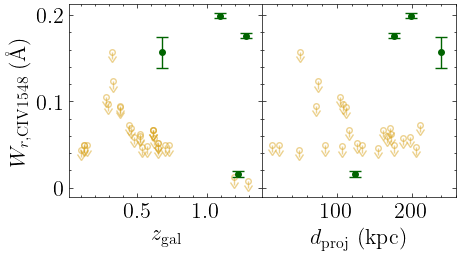

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(2.5*2,2.5), sharey=True)

for i in range(len(z_arr)):
    
    z = z_arr[i]
    d_proj = d_proj_arr[i]
    W_str = W_arr[i]
    
    if W_str[0]=='<':
        W = float(W_str[1:])
        
        # Plot marker and spear, z
        (_,caps,_) = axes[0].errorbar(z, W, xerr=None, yerr=5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color='goldenrod', markerfacecolor='none', alpha=.5)
        caps[0].set_fillstyle('none')
        
        # Connect
        axes[0].errorbar(z, W, xerr=None, yerr=[[1.7*5],[0]], markersize=0,
                   linestyle='none', capsize=0, color='goldenrod', alpha=.5)   
        
        # Handle d_proj
        (_,caps,_) = axes[1].errorbar(d_proj, W, xerr=None, yerr=5, uplims=True, marker='o',
                                      markersize=4, capsize=0, elinewidth=0,
                                      color='goldenrod', markerfacecolor='none', alpha=.5)
        caps[0].set_fillstyle('none')
        
        # Connect
        axes[1].errorbar(d_proj, W, xerr=None, yerr=[[1.7*5],[0]], markersize=0,
                   linestyle='none', capsize=0, color='goldenrod', alpha=.5)   
    
    elif W_str !='-10':
        W_split = W_str.split(',')
        W = float(W_split[0])
        dW = float(W_split[2])
        
        # Handle z
        axes[0].errorbar(z, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color='darkgreen', 
                         marker='o', markersize=4)
        
        # Handle d_proj
        axes[1].errorbar(d_proj, W, xerr=None, yerr=dW, capsize=4, linestyle='none', color='darkgreen', 
                         marker='o', markersize=4)
        
axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')


axes[1].set_xlim(0.01,260)
axes[1].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')

plt.subplots_adjust(wspace=0, hspace=0)

axes[0].set_yticks([0,100,200], [0,.1,.2])

#plt.savefig(rootdir+'Figures/CIV_sample.pdf', dpi=300)

In [38]:
def process_data_str(s, non_det_err):
    
    # Check if the point should be plotted or not
    bool_plot = False
    # Coordinate value
    coord_value = np.nan
    # Lower error
    err_lo = 0
    # Upper error
    err_hi = 0
    # Boolean for upper limit
    uplim = False
    # Boolean for lower limit
    lolim = False
    
    # If we don't have an empty string 
    if len(s)!=0:
        
        # Then it needs to be plotted
        bool_plot = True
        
        # Now, check for a non-detection first
        
        # Upper limit
        if s[0] == '<':
            # Set coordinate value
            coord_value = float(s[1:])
            # Only lower error
            uplim = True
            err_lo = non_det_err
            
        # Lower limit
        elif s[0] == '>':
            # Set coordinate value
            coord_value = float(s[1:])
            # Only upper error
            lolim = True
            err_hi = non_det_err
            
        # Detection
        else:
            s_arr = np.array(s.split(','), dtype=float)
            
            # Errors not provided
            if len(s_arr) == 1:
                coord_value = s_arr[0]
                err_lo = 0
                err_hi = 0
                
            # Errors provided
            else:
                coord_value = s_arr[0]
                err_lo = -s_arr[1] # Negative sign to flip the already present negative sign
                err_hi = s_arr[2]
        
    return bool_plot, coord_value, err_lo, err_hi, uplim, lolim

In [39]:
def plot_data_strings(ax, s_x, s_y, c, m, non_det_err_x=0.3, non_det_err_y=0.3, alpha=1):
    
    # First process each data string
    bool_plot_x, coord_value_x, err_lo_x, err_hi_x, uplim_x, lolim_x = process_data_str(s_x, non_det_err_x)
    bool_plot_y, coord_value_y, err_lo_y, err_hi_y, uplim_y, lolim_y = process_data_str(s_y, non_det_err_y)

    ax.errorbar(x=coord_value_x, y=coord_value_y,
                xerr=[[err_lo_x], [err_hi_x]],
                yerr=[[err_lo_y], [err_hi_y]], 
                color=c, alpha=alpha,
                marker=m, markersize=4.5, capsize=2, elinewidth=0.7,
                xuplims = uplim_x, xlolims= lolim_x,
                uplims = uplim_y, lolims= lolim_y) 

Compare column densities and linewidths for species

In [40]:
def compare_plot(ax, list_1, list_2, non_det_err_x, non_det_err_y, c):

    for i in range(len(list_1)):
        
        plot_data_strings(ax, list_1[i], list_2[i], 
                          c, 'o', 
                          non_det_err_x=non_det_err_x, non_det_err_y=non_det_err_y)

In [41]:
#z_list

In [42]:
z_non_det_list = []
d_proj_non_det_list = []
CIV_EW_non_det_list = []

z_det_list = []
d_proj_det_list = []
CIV_EW_det_list = []

for i in range(len(CIV_EW_list)):
    
    if CIV_EW_list[i][0] == '<':
        z_non_det_list.append(z_list[i])
        d_proj_non_det_list.append(d_proj_list[i])
        CIV_EW_non_det_list.append(CIV_EW_list[i])
        
    elif CIV_EW_list[i][0] == '-':
        pass
    
    else:
        z_det_list.append(z_list[i])
        d_proj_det_list.append(d_proj_list[i])
        CIV_EW_det_list.append(CIV_EW_list[i])

In [43]:
z_det_list

['0.678', '1.0959', '1.2256', '1.2787']

In [44]:
d_proj_det_list

['239.03717708741937',
 '199.41643493201175',
 '124.5089103015174',
 '176.0629134202478']

In [45]:
z_non_gal_list = ['1.0443', '1.1659', '1.2594']
CIV_EW_non_gal_list = ['342, -7, +7', '120, -4, +4', '13, -3, +3']

In [46]:
#z_group_list = ['0.6164', '0.6174', '0.6178']
#d_proj_group_list = ['398.253834', '117.581142', '163.708001']
#CIV_EW_group_list = ['254, -22, +22', '254, -22, +22', '254, -22, +22']

Text(0.5, 0, '$d_\\mathrm{proj}$ (kpc)')

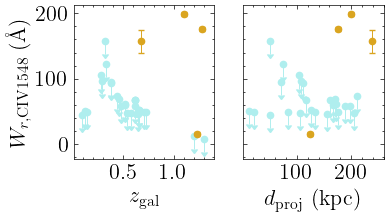

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(2*2,2), sharey=True)

compare_plot(axes[0], z_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[0], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')

compare_plot(axes[1], d_proj_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[1], d_proj_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[1].set_xlim(0.01,260)
axes[1].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')


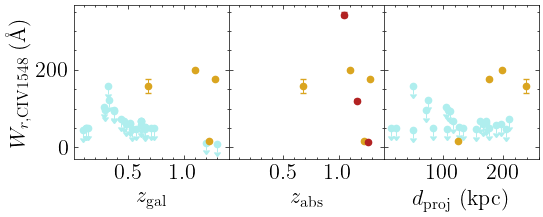

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(3*2,2), sharey=True)

compare_plot(axes[0], z_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[0], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')

axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')

compare_plot(axes[1], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
compare_plot(axes[1], z_non_gal_list, CIV_EW_non_gal_list, 0.3, 20, 'firebrick')
axes[1].set_xlim(0.01,1.4)
axes[1].set_xlabel(r'$z_\mathrm{abs}$')

compare_plot(axes[2], d_proj_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[2], d_proj_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[2].set_xlim(0.01,260)
axes[2].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')

#ax.set_ylim(-6,269)

plt.subplots_adjust(wspace=0, hspace=0)

#plt.savefig(rootdir+'CIV_sample.pdf', dpi=300)